In [1]:
import ee
import geemap
import os
from google.colab import files
import geopandas as gpd
import json
import numpy as np
from glob import glob
from google.colab import drive
import matplotlib.pyplot as plt

# Authenticate and initialize
ee.Authenticate()
ee.Initialize(project='gee-tutorial-470209')


MessageError: Error: credential propagation was unsuccessful

In [ ]:
# Define the desired directory path
target_directory = '/content/Aoi'

uploaded = files.upload(target_directory)

Saving AOI_Ganges_Padam_8.geojson to /content/Aoi/AOI_Ganges_Padam_8.geojson


In [ ]:

# Load GeoJSON
with open("/content/Aoi/AOI_Ganges_Padam_8.geojson") as f:
    geojson_data = json.load(f)

# Convert to EE Geometry or FeatureCollection
roi = ee.FeatureCollection(geojson_data)


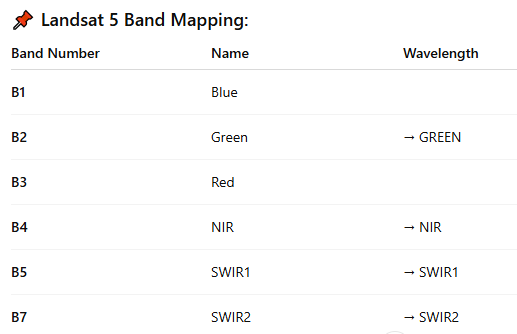

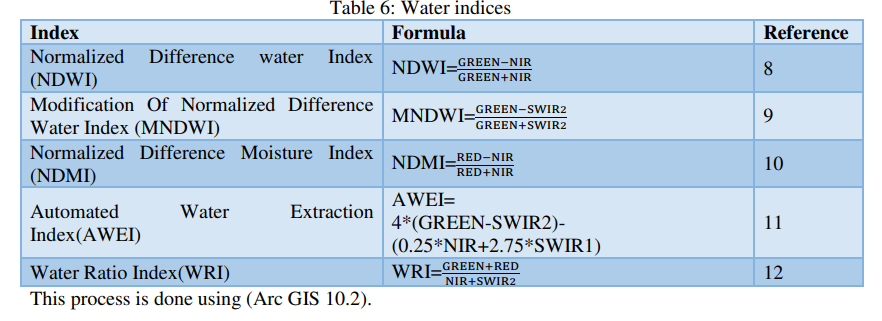

# **✅ Landsat 5 (LT05) — Post-Monsoon Water Masks**

In [ ]:
def scale_landsat5(img):
    sr = img.select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'])
    scaled = sr.multiply(0.0000275).add(-0.2)
    return img.addBands(scaled, overwrite=True)

def get_ls5_water_mask(year):
    start = f"{year-1}-11-01"
    end = f"{year}-04-01"

    col = (ee.ImageCollection("LANDSAT/LT05/C02/T1_L2")
           .filterBounds(roi)
           .filterDate(start, end)
           .filter(ee.Filter.lt("CLOUD_COVER", 10))
           .map(scale_landsat5))

    if col.size().getInfo() == 0:
        print(f"No Water Mask images for LS5 year {year}, skipping...")
        return None

    median = col.median().clip(roi)

    # Compute MNDWI and water mask
    mndwi = median.normalizedDifference(['SR_B2', 'SR_B5']).rename('NDWI')
    mask = mndwi.gt(0.).selfMask().rename('awei')

    # Reproject to UTM Zone 45N
    mask_utm45 = mask.reproject(crs='EPSG:32645', scale=30)

    # Add meta data
    mask_utm45 = mask_utm45.set({'year': year, 'source': 'LS5'})

    # Convert raster mask to vector polygons
    water_vectors = mask_utm45.addBands(mndwi).reduceToVectors(
        geometry=roi,
        crs='EPSG:32645',
        scale=30,
        geometryType='polygon',
        labelProperty='water',
        reducer=ee.Reducer.mean()
    )

    # Add area and filter > 10,000 m²
    def add_area(feature):
        area = feature.geometry().area(1)  # m²
        return feature.set({'area': area})

    water_with_area = water_vectors.map(add_area)
    large_water = water_with_area.filter(ee.Filter.gte('area', 1000000))

    # Add metadata
    large_water = large_water.map(lambda f: f.set({'year': year, 'source': 'LS5'}))
    # Add metadata to mndwi
    # mndwi = mndwi.set({'year': year, 'source': 'LS5'})

    return mask_utm45



# RGB Image collection
def get_rgb_image_collection(year):
    start = f"{year-1}-11-01"
    end = f"{year}-04-01"
    col_rgb =  (ee.ImageCollection("LANDSAT/LT05/C02/T1_L2")
                .filterBounds(roi)
                .filterDate(start, end)
                .filter(ee.Filter.lt("CLOUD_COVER", 10))
                .map(scale_landsat5)
                .select(['SR_B4', 'SR_B3', 'SR_B2']))
    if col_rgb.size().getInfo() == 0:
        print(f"No RGB images for LS5 year {year}, skipping...")
        return None
    median_rgb = col_rgb.median().clip(roi)
    return median_rgb.set({'year': year, 'source': 'LS5'})


ls5_color_image = []
ls5_ndwi_mask = []


for year in range(1988,2012):   #
    rgb = get_rgb_image_collection(year)
    if rgb:
        ls5_color_image.append(rgb)

    water_masks = get_ls5_water_mask(year)
    if water_masks:
        ls5_ndwi_mask.append(water_masks)

print(len(ls5_color_image))
print(len(ls5_ndwi_mask))


No RGB images for LS5 year 2002, skipping...
No Water Mask images for LS5 year 2002, skipping...
No RGB images for LS5 year 2003, skipping...
No Water Mask images for LS5 year 2003, skipping...
22
22


# Export Mask Tiif

In [ ]:
import time
for img in ls5_ndwi_mask:
    year = img.get("year").getInfo()
    task = ee.batch.Export.image.toDrive(
        image=img,
        description=f"FID_08_{year}_LS5_Water_Mask",
        folder="FID_08_LS5_Mask_Tiff",
        fileNamePrefix=f"FID_08_{year}_LS5_Water_Mask",
        region=roi.geometry().bounds().getInfo()["coordinates"],
        scale=30,
        crs='EPSG:32645',
        maxPixels=1e13
    )
    task.start()
    print(f"🚀 LS5 Water Mask export started for {year}")
    time.sleep(5)

🚀 LS5 Water Mask export started for 1988
🚀 LS5 Water Mask export started for 1989
🚀 LS5 Water Mask export started for 1990
🚀 LS5 Water Mask export started for 1991
🚀 LS5 Water Mask export started for 1992
🚀 LS5 Water Mask export started for 1993
🚀 LS5 Water Mask export started for 1994
🚀 LS5 Water Mask export started for 1995
🚀 LS5 Water Mask export started for 1996
🚀 LS5 Water Mask export started for 1997
🚀 LS5 Water Mask export started for 1998
🚀 LS5 Water Mask export started for 1999
🚀 LS5 Water Mask export started for 2000
🚀 LS5 Water Mask export started for 2001
🚀 LS5 Water Mask export started for 2004
🚀 LS5 Water Mask export started for 2005
🚀 LS5 Water Mask export started for 2006
🚀 LS5 Water Mask export started for 2007
🚀 LS5 Water Mask export started for 2008
🚀 LS5 Water Mask export started for 2009
🚀 LS5 Water Mask export started for 2010
🚀 LS5 Water Mask export started for 2011


# Export color image

In [ ]:
import time
for img in ls5_color_image:
    year = img.get("year").getInfo()
    task = ee.batch.Export.image.toDrive(
        image=img,
        description=f"FID_08_{year}_LS5_Ganges_Color_Image",
        folder="FID_08_LS5_Ganges_Color_Image",
        fileNamePrefix=f"FID_08_{year}_LS5_Ganges_Color_Image",
        region=roi.geometry().bounds().getInfo()["coordinates"],
        scale=30,
        crs='EPSG:32645',
        maxPixels=1e13
    )
    task.start()
    print(f"🚀 LS5 Color NIR_R_G export started for {year}")
    time.sleep(15)

🚀 LS5 Color NIR_R_G export started for 1988
🚀 LS5 Color NIR_R_G export started for 1989
🚀 LS5 Color NIR_R_G export started for 1990
🚀 LS5 Color NIR_R_G export started for 1991
🚀 LS5 Color NIR_R_G export started for 1992
🚀 LS5 Color NIR_R_G export started for 1993
🚀 LS5 Color NIR_R_G export started for 1994
🚀 LS5 Color NIR_R_G export started for 1995
🚀 LS5 Color NIR_R_G export started for 1996
🚀 LS5 Color NIR_R_G export started for 1997
🚀 LS5 Color NIR_R_G export started for 1998
🚀 LS5 Color NIR_R_G export started for 1999
🚀 LS5 Color NIR_R_G export started for 2000
🚀 LS5 Color NIR_R_G export started for 2001
🚀 LS5 Color NIR_R_G export started for 2004
🚀 LS5 Color NIR_R_G export started for 2005
🚀 LS5 Color NIR_R_G export started for 2006
🚀 LS5 Color NIR_R_G export started for 2007
🚀 LS5 Color NIR_R_G export started for 2008
🚀 LS5 Color NIR_R_G export started for 2009
🚀 LS5 Color NIR_R_G export started for 2010
🚀 LS5 Color NIR_R_G export started for 2011


# Export Water polygon

In [ ]:
import time

for fc in ls5_ndwi_mask:
    # Each element in ls5_ndwi is a FeatureCollection with 'year' metadata
    year = fc.first().get('year').getInfo()  # Extract year from properties

    task = ee.batch.Export.table.toDrive(
        collection=fc,
        description=f"FID_08_{year}_LS5_Ganges_WaterPolygon",
        folder="FID_08_LS5_Ganges_WaterPolygon",
        fileNamePrefix=f"FID_08_{year}_LS5_Ganges_WaterPolygon",
        fileFormat='GeoJSON'
    )
    task.start()
    print(f"💧 Water polygon GeoJSON export started for {year}")

    # Sleep to avoid too many simultaneous tasks
    time.sleep(5)


💧 Water polygon GeoJSON export started for 1988
💧 Water polygon GeoJSON export started for 1989
💧 Water polygon GeoJSON export started for 1990
💧 Water polygon GeoJSON export started for 1991
💧 Water polygon GeoJSON export started for 1992
💧 Water polygon GeoJSON export started for 1993
💧 Water polygon GeoJSON export started for 1994
💧 Water polygon GeoJSON export started for 1995
💧 Water polygon GeoJSON export started for 1996
💧 Water polygon GeoJSON export started for 1997
💧 Water polygon GeoJSON export started for 1998
💧 Water polygon GeoJSON export started for 1999
💧 Water polygon GeoJSON export started for 2000
💧 Water polygon GeoJSON export started for 2001
💧 Water polygon GeoJSON export started for 2004
💧 Water polygon GeoJSON export started for 2005
💧 Water polygon GeoJSON export started for 2006
💧 Water polygon GeoJSON export started for 2007
💧 Water polygon GeoJSON export started for 2008
💧 Water polygon GeoJSON export started for 2009
💧 Water polygon GeoJSON export started f

# **✅ Water Mask (NDWI) Export Landsat 7**

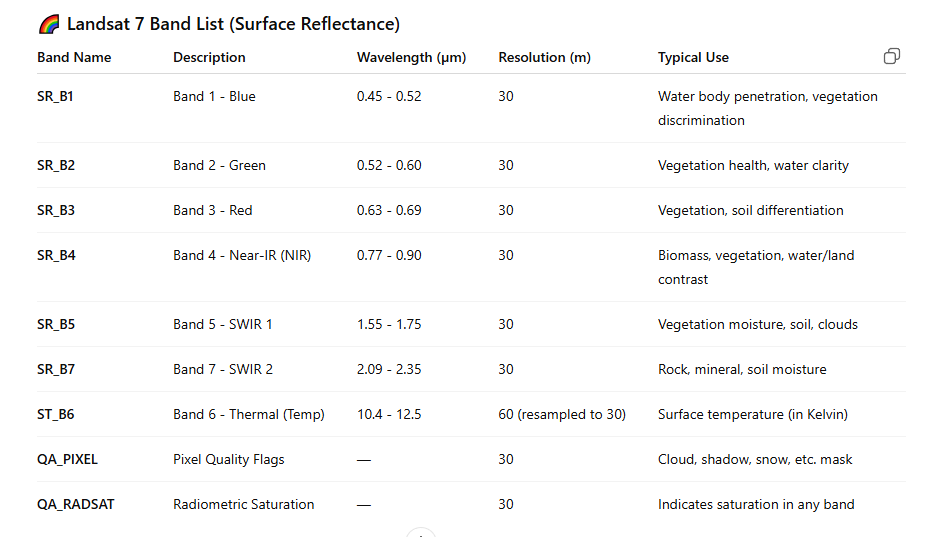

In [ ]:
def scale_landsat7(img):
    sr = img.select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'])
    scaled = sr.multiply(0.0000275).add(-0.2)
    return img.addBands(scaled, overwrite=True)

def get_ls7_water_mask(year):
    start = f"{year-1}-11-01"
    end = f"{year}-04-01"

    col = (ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")
           .filterBounds(roi)
           .filterDate(start, end)
           .filter(ee.Filter.lt("CLOUD_COVER", 10))
           .map(scale_landsat7))

    if col.size().getInfo() == 0:
        print(f"No Water Mask images for LS7 year {year}, skipping...")
        return None

    median = col.median().clip(roi)
    mndwi = median.normalizedDifference(['SR_B2', 'SR_B4']).rename('MNDWI')
    mask = mndwi.gt(0.0).selfMask().rename('awei')
    # Reproject to UTM Zone 45N
    mask_utm45 = mask.reproject(crs='EPSG:32645', scale=30)

    # Convert raster mask to vector polygons
    water_vectors = mask_utm45.addBands(mndwi).reduceToVectors(
        geometry=roi,
        crs='EPSG:32645',
        scale=30,
        geometryType='polygon',
        labelProperty='water',
        reducer=ee.Reducer.mean()
    )

    # Add area and filter > 10,000 m²
    def add_area(feature):
        area = feature.geometry().area(1)  # m²
        return feature.set({'area': area})

    water_with_area = water_vectors.map(add_area)
    large_water = water_with_area.filter(ee.Filter.gte('area', 10000))

    # Add metadata
    large_water = large_water.map(lambda f: f.set({'year': year, 'source': 'LS7'}))
    return large_water

def get_ls7_rgb_image_collection(year):
    start = f"{year-1}-11-01"
    end = f"{year}-04-01"

    col_rgb = (ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")
               .filterBounds(roi)
               .filterDate(start, end)
               .filter(ee.Filter.lt("CLOUD_COVER", 10))
               .map(scale_landsat7)
               .select(['SR_B4', 'SR_B3', 'SR_B2']))

    if col_rgb.size().getInfo() == 0:
        print(f"No RGB images for LS7 year {year}, skipping...")
        return None

    median_rgb = col_rgb.median().clip(roi)
    return median_rgb.set({'year': year, 'source': 'LS7'})

# Process LS7 data
ls7_color_image = []
ls7_Water_Polygon = []

for year in [2002, 2003, 2012 ,2013]:  # LS7 launched in 1999
    rgb = get_ls7_rgb_image_collection(year)
    if rgb:
        ls7_color_image.append(rgb)

    water_mask = get_ls7_water_mask(year)
    if water_mask:
        ls7_Water_Polygon.append(water_mask)

print(len(ls7_color_image))
print(len(ls7_Water_Polygon))


4
4


# Export color Image

In [ ]:
import time
for img in ls7_color_image:
    year = img.get("year").getInfo()
    task = ee.batch.Export.image.toDrive(
        image=img,
        description=f"FID_06_{year}_LS7_Ganges_Color_Image",
        folder="FID_06_LS7_Ganges_Color_Image",
        fileNamePrefix=f"FID_06_{year}_LS7_Ganges_Color_Image",
        region=roi.geometry().bounds().getInfo()["coordinates"],
        scale=30,
        crs='EPSG:32645',
        maxPixels=1e13
    )
    task.start()
    print(f"🚀 LS7 Color SWIR1_R_G export started for {year}")
    time.sleep(15)

🚀 LS7 Color SWIR1_R_G export started for 2002
🚀 LS7 Color SWIR1_R_G export started for 2003
🚀 LS7 Color SWIR1_R_G export started for 2012
🚀 LS7 Color SWIR1_R_G export started for 2013


# Water Polygon Export

In [ ]:
import time

for fc in ls7_Water_Polygon:
    # Each element in ls5_ndwi is a FeatureCollection with 'year' metadata
    year = fc.first().get('year').getInfo()  # Extract year from properties

    task = ee.batch.Export.table.toDrive(
        collection=fc,
        description=f"FID_06_{year}_LS7_Ganges_WaterPolygon",
        folder="FID_06_LS7_Ganges_WaterPolygon",
        fileNamePrefix=f"FID_06_{year}_LS7_Ganges_WaterPolygon",
        fileFormat='GeoJSON'
    )
    task.start()
    print(f"💧 Water polygon GeoJSON export started for {year}")

    # Sleep to avoid too many simultaneous tasks
    time.sleep(5)

💧 Water polygon GeoJSON export started for 2002
💧 Water polygon GeoJSON export started for 2003
💧 Water polygon GeoJSON export started for 2012
💧 Water polygon GeoJSON export started for 2013


# ✅ **Landsat 8 (LC08) — Post-Monsoon Water Masks (2014–2024)**

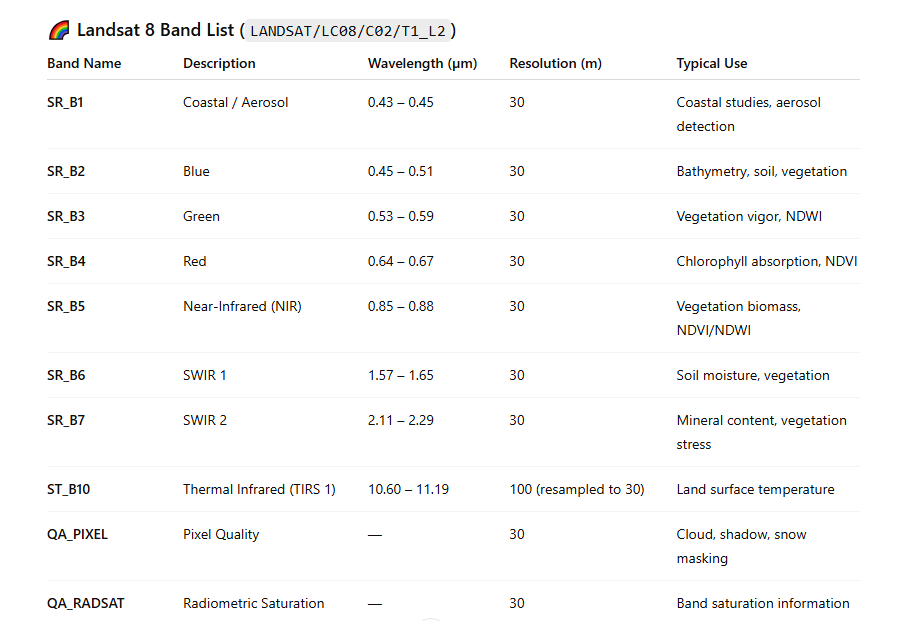

In [ ]:
def scale_landsat8(img):
    sr = img.select(['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7'])
    scaled = sr.multiply(0.0000275).add(-0.2)
    return img.addBands(scaled, overwrite=True)

def get_ls8_water_mask(year):
    start = f"{year-1}-11-01"
    end = f"{year}-04-01"

    col = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
           .filterBounds(roi)
           .filterDate(start, end)
           .filter(ee.Filter.lt("CLOUD_COVER", 10))
           .map(scale_landsat8))

    if col.size().getInfo() == 0:
        print(f"No Water Mask images for LS8 year {year}, skipping...")
        return None

    median = col.median().clip(roi)
    mndwi = median.normalizedDifference(['SR_B3', 'SR_B5']).rename('MNDWI')  # Green & NIR
    mask = mndwi.gt(-0.20).selfMask().rename('awei')
    # Reproject to UTM Zone 45N
    mask_utm45 = mask.reproject(crs='EPSG:32645', scale=30)

    # Convert raster mask to vector polygons
    water_vectors = mask_utm45.addBands(mndwi).reduceToVectors(
        geometry=roi,
        crs='EPSG:32645',
        scale=30,
        geometryType='polygon',
        labelProperty='water',
        reducer=ee.Reducer.mean()
    )

    # Add area and filter > 10,000 m²
    def add_area(feature):
        area = feature.geometry().area(1)  # m²
        return feature.set({'area': area})

    water_with_area = water_vectors.map(add_area)
    large_water = water_with_area.filter(ee.Filter.gte('area', 10000))

    # Add metadata
    large_water = large_water.map(lambda f: f.set({'year': year, 'source': 'LS8'}))
    return large_water

def get_ls8_rgb_image_collection(year):
    start = f"{year-1}-11-01"
    end = f"{year}-04-01"

    col_rgb = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
               .filterBounds(roi)
               .filterDate(start, end)
               .filter(ee.Filter.lt("CLOUD_COVER", 10))
               .map(scale_landsat8)
               .select(['SR_B5', 'SR_B4', 'SR_B3']))  # SWIR1, NIR, Red (False Color)

    if col_rgb.size().getInfo() == 0:
        print(f"No RGB images for LS8 year {year}, skipping...")
        return None

    median_rgb = col_rgb.median().clip(roi)
    return median_rgb.set({'year': year, 'source': 'LS8'})

# Process LS8 data
ls8_color_image = []
ls8_water_polygon = []

for year in range(2012,2027):  # LS8 launched in 2013
    rgb = get_ls8_rgb_image_collection(year)
    if rgb:
        ls8_color_image.append(rgb)

    water_mask = get_ls8_water_mask(year)
    if water_mask:
        ls8_water_polygon.append(water_mask)

print(len(ls8_color_image))
print(len(ls8_water_polygon))


No RGB images for LS8 year 2012, skipping...
No Water Mask images for LS8 year 2012, skipping...
No RGB images for LS8 year 2013, skipping...
No Water Mask images for LS8 year 2013, skipping...
13
13


In [ ]:
import time
for img in ls8_color_image:
    year = img.get("year").getInfo()
    task = ee.batch.Export.image.toDrive(
        image=img,
        description=f"FID_06_{year}_LS8_Ganges_Color_Image",
        folder="FID_06_LS8_Ganges_Color_Image",
        fileNamePrefix=f"FID_06_{year}_LS8_Ganges_Color_Image",
        region=roi.geometry().bounds().getInfo()["coordinates"],
        scale=30,
        crs='EPSG:32645',
        maxPixels=1e13
    )
    task.start()
    print(f"🚀 LS8 Color NIR1_R_G export started for {year}")
    time.sleep(10)

🚀 LS8 Color NIR1_R_G export started for 2014
🚀 LS8 Color NIR1_R_G export started for 2015
🚀 LS8 Color NIR1_R_G export started for 2016
🚀 LS8 Color NIR1_R_G export started for 2017
🚀 LS8 Color NIR1_R_G export started for 2018
🚀 LS8 Color NIR1_R_G export started for 2019
🚀 LS8 Color NIR1_R_G export started for 2020
🚀 LS8 Color NIR1_R_G export started for 2021
🚀 LS8 Color NIR1_R_G export started for 2022
🚀 LS8 Color NIR1_R_G export started for 2023
🚀 LS8 Color NIR1_R_G export started for 2024
🚀 LS8 Color NIR1_R_G export started for 2025
🚀 LS8 Color NIR1_R_G export started for 2026


# Export Water Polygon

In [ ]:
import time

for fc in ls8_water_polygon:
    # Each element in ls5_ndwi is a FeatureCollection with 'year' metadata
    year = fc.first().get('year').getInfo()  # Extract year from properties

    task = ee.batch.Export.table.toDrive(
        collection=fc,
        description=f"FID_06_{year}_LS8_Ganges_WaterPolygon",
        folder="FID_06_LS8_Ganges_WaterPolygon",
        fileNamePrefix=f"FID_06_{year}_LS8_Ganges_WaterPolygon",
        fileFormat='GeoJSON'
    )
    task.start()
    print(f"💧 Water polygon GeoJSON export started for {year}")

    # Sleep to avoid too many simultaneous tasks
    time.sleep(5)

💧 Water polygon GeoJSON export started for 2014
💧 Water polygon GeoJSON export started for 2015
💧 Water polygon GeoJSON export started for 2016
💧 Water polygon GeoJSON export started for 2017
💧 Water polygon GeoJSON export started for 2018
💧 Water polygon GeoJSON export started for 2019
💧 Water polygon GeoJSON export started for 2020
💧 Water polygon GeoJSON export started for 2021
💧 Water polygon GeoJSON export started for 2022
💧 Water polygon GeoJSON export started for 2023
💧 Water polygon GeoJSON export started for 2024
💧 Water polygon GeoJSON export started for 2025
💧 Water polygon GeoJSON export started for 2026


# Export Water Mask LS 8

# Sentinel 2 Image Collection

In [ ]:
# ---------------------------
# 2️⃣ Sentinel-2 scaling & selection
# ---------------------------
def scale_sentinel2(img):
    """Scale and keep consistent Sentinel-2 bands."""
    sr = img.select(['B2', 'B3', 'B4', 'B8', 'B11'])  # Blue, Green, Red, NIR, SWIR
    scaled = sr.multiply(0.0001)
    return scaled.copyProperties(img, img.propertyNames())

# ---------------------------
# 3️⃣ Compute NDWI-based water polygons for a given year
# ---------------------------
def get_s2_water_mask(year):
    start = f"{year}-01-01"
    end = f"{year+1}-10-30"

    # Use harmonized collection for consistent band structure
    col = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
           .filterBounds(roi)
           .filterDate(start, end)
           .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 10))
           .map(scale_sentinel2))

    if col.size().getInfo() == 0:
        print(f"No Water Mask images for S2 year {year}, skipping...")
        return None

    median = col.median().clip(roi)

    # NDWI (Green - NIR) / (Green + NIR)
    ndwi = median.normalizedDifference(['B3', 'B8']).rename('NDWI')
    mask = ndwi.gt(0.0).selfMask().rename('NDWI')

    # Reproject to UTM 45N
    mask_utm45 = mask.reproject(crs='EPSG:32646', scale=10)

    # Vectorize NDWI mask
    water_vectors = mask_utm45.reduceToVectors(
        geometry=roi,
        crs='EPSG:32646',
        scale=10,
        geometryType='polygon',
        labelProperty='water',
        reducer=ee.Reducer.countEvery()

    )

    # Add area and filter > 10,000 m²
    def add_area(feature):
        area = feature.geometry().area(1)
        return feature.set({'area': area})

    large_water = water_vectors.map(add_area).filter(ee.Filter.gte('area', 100))
    return large_water.map(lambda f: f.set({'year': year, 'source': 'S2'}))

# ---------------------------
# 4️⃣ RGB composite generator
# ---------------------------
def get_rgb_image_collection(year):
    start = f"{year}-01-01"
    end = f"{year+1}-10-30"
    col_rgb = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
               .filterBounds(roi)
               .filterDate(start, end)
               .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 10))
               .map(scale_sentinel2)
               .select(['B8', 'B4', 'B3']))  # Red, Green, Blue

    if col_rgb.size().getInfo() == 0:
        print(f"No RGB images for S2 year {year}, skipping...")
        return None

    median_rgb = col_rgb.median().clip(roi)
    return median_rgb.set({'year': year, 'source': 'S2'})

# ---------------------------
# 5️⃣ Build image lists by year
# ---------------------------
s2_color_image = []
s2_ndwi = []

for year in [2023,2024]:
    rgb = get_rgb_image_collection(year)
    if rgb:
        s2_color_image.append(rgb)

    water_masks = get_s2_water_mask(year)
    if water_masks:
        s2_ndwi.append(water_masks)

print("✅ RGB years:", len(s2_color_image))
print("✅ NDWI years:", len(s2_ndwi))

✅ RGB years: 2
✅ NDWI years: 2


In [ ]:
import geemap
import ipywidgets as widgets
from IPython.display import display

# ---------------------------
# 6️⃣ Interactive Map
# ---------------------------
Map = geemap.Map()
Map.centerObject(roi, 10)

# Build year-layer dictionary
year_options = []
year_to_layers = {}

for i in range(len(s2_ndwi)):
    year = s2_ndwi[i].first().get('year').getInfo()
    year_options.append(str(year))
    year_to_layers[str(year)] = {
        'rgb': s2_color_image[i],
        'water_polygons': s2_ndwi[i]
    }

# Dropdown widget
dropdown = widgets.Dropdown(
    options=year_options,
    description='Select Year:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

# Function to update layers on map
def on_year_change(change):
    Map.layers = [Map.layers[0]]  # clear previous layers except base
    year = change['new']
    rgb_image = year_to_layers[year]['rgb']
    water_polygons = year_to_layers[year]['water_polygons']

    # Add RGB composite
    Map.addLayer(
        rgb_image,
        {'bands': ['B8', 'B4', 'B3'], 'min': 0, 'max': 0.3},
        f'Sentinel-2 RGB ({year})'
    )

    # Add NDWI polygons
    Map.addLayer(
        water_polygons.style(**{
            'color': '00FFFF',       # Cyan boundary
            'fillColor': '0000FF55', # Semi-transparent blue
            'width': 1
        }),
        {},
        f'Water Polygons >10,000 m² ({year})'
    )

# Connect dropdown to map
dropdown.observe(on_year_change, names='value')

# Display widgets and map
display(dropdown)
display(Map)

# Show first year automatically
dropdown.value = year_options[0]

Dropdown(description='Select Year:', layout=Layout(width='300px'), options=('2023', '2024'), style=Description…

Map(center=[22.903877751082625, 91.34351155033995], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
import time
for fc in s2_ndwi:
    # Each element in ls5_ndwi is a FeatureCollection with 'year' metadata
    year = fc.first().get('year').getInfo()  # Extract year from properties

    task = ee.batch.Export.table.toDrive(
        collection=fc,
        description=f"{year}_S2_Padma_Harirampur_WaterPolygon",
        folder="S2_Padma_Harirampur_WaterPolygon",
        fileNamePrefix=f"{year}_S2_Padma_Harirampur_WaterPolygon",
        fileFormat='GeoJSON'

    )
    task.start()
    print(f"💧 Water polygon GeoJSON export started for {year}")

    # Sleep to avoid too many simultaneous tasks
    time.sleep(5)

In [ ]:
import time
for img in s2_color_image:
    year = img.get("year").getInfo()
    task = ee.batch.Export.image.toDrive(
        image=img,
        description=f"{year}_S2_Padma_Harirampur_NIR_R_G",
        folder="S2_Padma_Harirampur_NIR_R_G",
        fileNamePrefix=f"{year}_S2_Padma_Harirampur_NIR_R_G",
        region=roi.geometry().bounds().getInfo()["coordinates"],
        scale=10,
        crs='EPSG:32645',
        maxPixels=1e13
    )
    task.start()
    print(f"🚀 LS8 Color SWIR1_R_G export started for {year}")
    time.sleep(30)